In [51]:
import string
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import spacy
nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [52]:
df = pd.read_csv('df_total.csv')

TEXT_COL = "news"
CATEGORY_COL = "Type"

print(df.shape)
df.head()

(1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


**¿Cuántos documentos tiene el corpus?:** El corpus contiene 1,217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?:** El corpus contiene 3 columnas en donde se guarda el url, texto de la noticia (news) y una etiqueta que hace referencia al tipo de noticia (type).

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


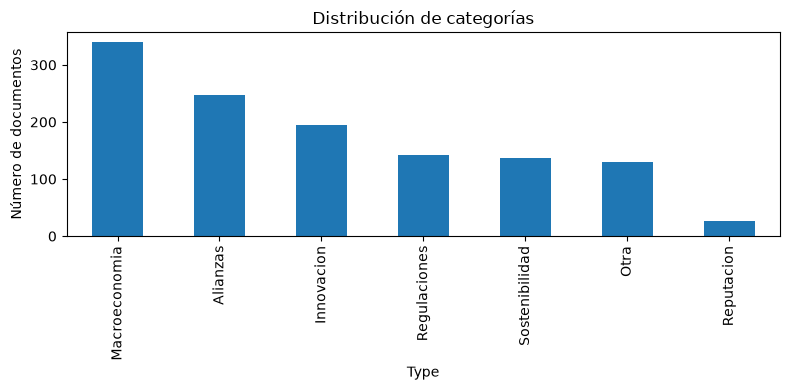

In [53]:
categorias = df[CATEGORY_COL].value_counts()
print(categorias)

categorias.plot(kind='bar', figsize=(8,4), title='Distribución de categorías')
plt.ylabel('Número de documentos')
plt.tight_layout()
plt.show()

**¿Cuántas categorías hay y cómo se distribuyen?:** Existen 7 categorias unicas con la siguiente distribucion:
- Macroeconomia: 27.9%
- Alianzas: 20.3%
- Innovacion: 16.0%
- Regulaciones: 11.7%
- Sostenibilidad: 11.2%
- Otra: 10.7%
- Reputacion: 2.1%

In [54]:
# ¿Hay filas vacías o duplicadas?
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas completamente duplicadas:", df.duplicated().sum())
print("Textos duplicados:", df.duplicated(subset=[TEXT_COL]).sum())

Valores nulos por columna:
url     0
news    4
Type    0
dtype: int64

Filas completamente duplicadas: 75
Textos duplicados: 79


**¿Hay filas vacías o duplicadas?:** Se identificaron 4 filas con valores nulos en la columna 'news'. Además, existen 75 filas completamente duplicadas y se encontraron 79 registros con contenido duplicado en la columna 'news'.

In [55]:
df = df.dropna(subset=[TEXT_COL]).drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print("Shape final:", df.shape)

Shape final: (1137, 3)


---

In [56]:
def contar_tokens_tipos(columna_de_listas):
    todos = [tok for lista in columna_de_listas for tok in lista]
    return len(todos), len(set(todos))

pasos = []

In [57]:
# i. Tokenización
df['tokens'] = df[TEXT_COL].astype(str).apply(lambda x: word_tokenize(x, language='spanish'))
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Tokenización', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 631733 | Tipos: 38947


In [58]:
# ii. Minúsculas
df['tokens'] = df['tokens'].apply(lambda toks: [w.lower() for w in toks])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Minúsculas', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 631733 | Tipos: 36099


In [59]:
# iii. Eliminar puntuación
puntuacion = set(string.punctuation) | {'¿','¡','—','–','…','“','”','‘','’','»','«'}

def es_puntuacion(tok):
    return all(ch in puntuacion for ch in tok)

df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if not es_puntuacion(w)])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin puntuación', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 598379 | Tipos: 36066


In [60]:
# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if w not in stop_es])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin stopwords', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 318955 | Tipos: 35855


In [61]:
# v. Lematizar
textos_para_lematizar = df['tokens'].apply(lambda toks: ' '.join(toks))

lemas = []
for doc in nlp.pipe(textos_para_lematizar, batch_size=64):
    lemas.append([t.lemma_.lower() for t in doc if t.lemma_.strip() != ''])

df['tokens'] = lemas
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Lematizado', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 319421 | Tipos: 28806


In [62]:
pipeline = pd.DataFrame(pasos, columns=['Paso', 'Tokens', 'Tipos'])
pipeline['Tipo/Token'] = (pipeline['Tipos'] / pipeline['Tokens']).round(4)
pipeline

,Paso,Tokens,Tipos,Tipo/Token
0,Tokenización,631733,38947,0.0617
1,Minúsculas,631733,36099,0.0571
2,Sin puntuación,598379,36066,0.0603
3,Sin stopwords,318955,35855,0.1124
4,Lematizado,319421,28806,0.0902


---

EDA del corpus

In [63]:
# Tokens y tipos antes y después de la normalización

tokens_antes, tipos_antes = pasos[0][1], pasos[0][2]
tokens_despues, tipos_despues = pasos[-1][1], pasos[-1][2]

reduccion_vocab = (tipos_antes - tipos_despues) / tipos_antes * 100

print(f"Antes de normalizar   -> Tokens: {tokens_antes} | Tipos: {tipos_antes}")
print(f"Después de normalizar -> Tokens: {tokens_despues} | Tipos: {tipos_despues}")
print(f"Reducción del vocabulario: {reduccion_vocab:.1f}%")

Antes de normalizar   -> Tokens: 631733 | Tipos: 38947
Después de normalizar -> Tokens: 319421 | Tipos: 28806
Reducción del vocabulario: 26.0%


In [64]:
# Riqueza léxica

ttr_global = tipos_despues / tokens_despues
print(f"TTR global: {ttr_global:.4f}")

def ttr_por_categoria(df):
    resultados = {}
    for cat, grupo in df.groupby(CATEGORY_COL):
        todos = [tok for toks in grupo['tokens'] for tok in toks]
        resultados[cat] = len(set(todos)) / len(todos) if len(todos) > 0 else 0
    return pd.Series(resultados).sort_values(ascending=False)

ttr_categoria = ttr_por_categoria(df)
ttr_categoria

TTR global: 0.0902


Reputacion        0.350727
Regulaciones      0.216135
Otra              0.204993
Alianzas          0.203608
Sostenibilidad    0.154691
Innovacion        0.139511
Macroeconomia     0.127567
dtype: float64

In [65]:
# Top 20 palabras más frecuentes

all_tokens = [tok for toks in df['tokens'] for tok in toks]
frecuencias = Counter(all_tokens)

top20 = pd.DataFrame(frecuencias.most_common(20), columns=['Palabra', 'Frecuencia'])
top20

,Palabra,Frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


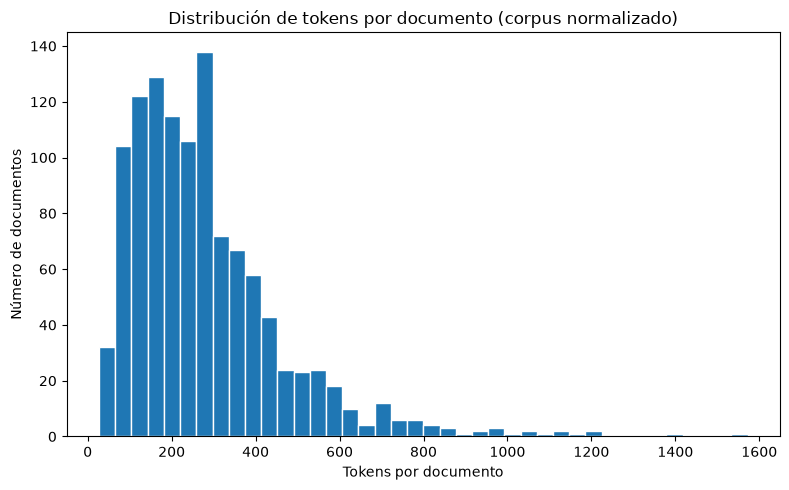

In [66]:
# Histograma de tokens por documento

df['n_tokens'] = df['tokens'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df['n_tokens'], bins=40, edgecolor='white')
plt.xlabel('Tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de tokens por documento (corpus normalizado)')
plt.tight_layout()
plt.show()

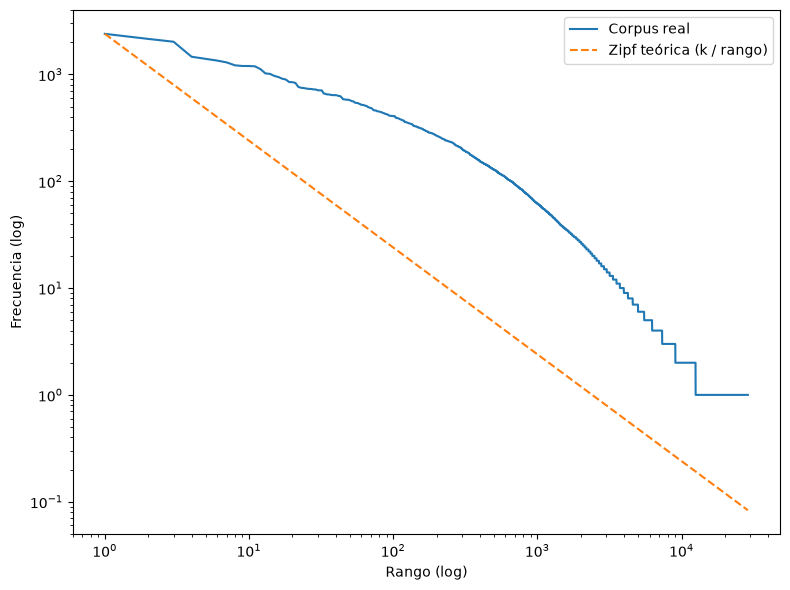

In [67]:
# Ley de Zipf: corpus real vs. curva teórica

frecuencias_ordenadas = np.array([f for _, f in frecuencias.most_common()])
rangos = np.arange(1, len(frecuencias_ordenadas) + 1)

k = frecuencias_ordenadas[0]
zipf_teorica = k / rangos

plt.figure(figsize=(8,6))
plt.loglog(rangos, frecuencias_ordenadas, label='Corpus real')
plt.loglog(rangos, zipf_teorica, linestyle='--', label='Zipf teórica (k / rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# Comparación por categoría (top 10 palabras mas frecuentes)

categorias_a_comparar = ["Macroeconomia", "Innovacion"]
for cat in categorias_a_comparar:
    tokens_cat = [tok for toks in df[df[CATEGORY_COL] == cat]['tokens'] for tok in toks]
    top10_cat = Counter(tokens_cat).most_common(10)
    print(f"\nTop 10 — {cat}:")
    for palabra, freq in top10_cat:
        print(f"  {palabra}: {freq}")


Top 10 — Macroeconomia:
  inflación: 1278
  precio: 986
  año: 905
  poder: 666
  tasa: 507
  mayor: 507
  bbva: 494
  mes: 489
  país: 430
  aumento: 416

Top 10 — Innovacion:
  bbva: 886
  poder: 496
  banco: 352
  digital: 338
  cliente: 323
  nuevo: 314
  dato: 298
  empresa: 283
  permitir: 259
  financiero: 247


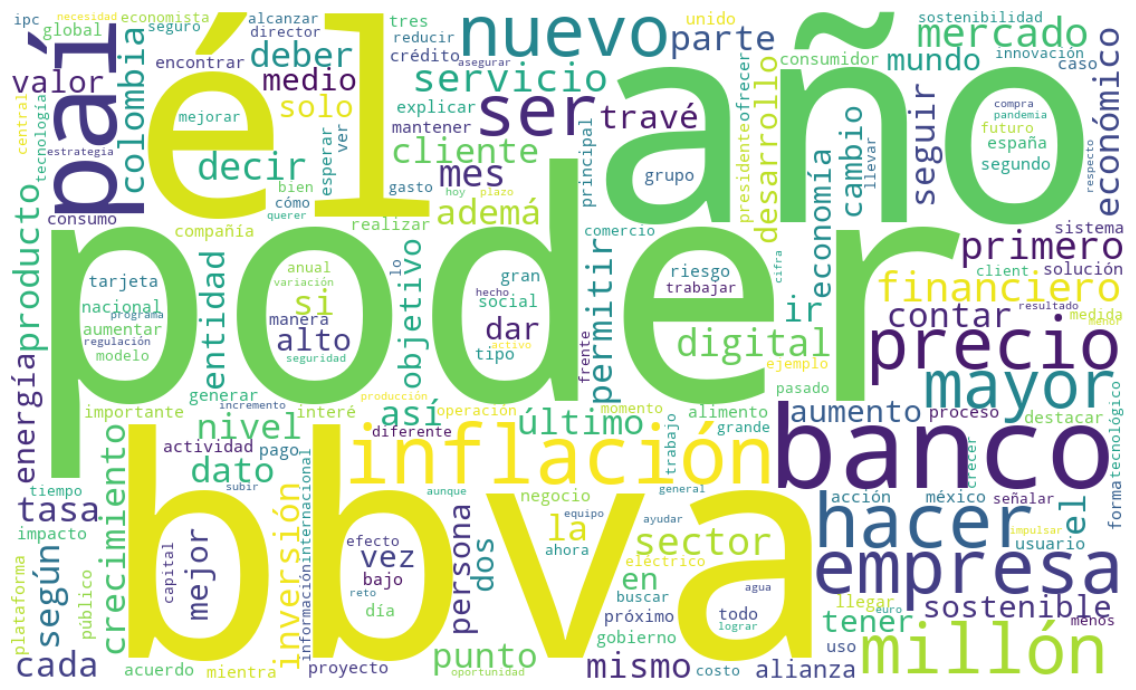

In [69]:
# Nube de palabras del vocabulario normalizado

from wordcloud import WordCloud

texto_completo = ' '.join(all_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_completo)

plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

---
---

## Laboratorio 2

#### 1. Bolsa de palabras (Bag of Words)

In [70]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_normalizado = df['tokens'].apply(lambda toks: ' '.join(toks))
vectorizer = CountVectorizer(lowercase=False)

X_bow = vectorizer.fit_transform(corpus_normalizado)

n_docs, vocab_size = X_bow.shape
print(f"Forma de la matriz BoW: {X_bow.shape}")
print(f"Número de documentos: {n_docs}")
print(f"Tamaño del vocabulario: {vocab_size}")

Forma de la matriz BoW: (1137, 23412)
Número de documentos: 1137
Tamaño del vocabulario: 23412


**Explique, con sus propias palabras, qué información se pierde al representar un documento como bolsa de palabras (orden, gramática, contexto) y qué se gana a cambio?**

Cuando se representa un documento como una bolsa de palabras, se tiende a perder el orden de las palabras, la gramática/estructura y el contexto en general de la información original. A cambio, se obtiene una representación numérica y se gana simplicidad y eficiencia para la construcción de modelos y la realización de cómputos rápidos.


---
#### 2. Vectores de conteo y dispersión 

In [71]:
total_celdas = X_bow.shape[0] * X_bow.shape[1]

celdas_no_cero = X_bow.nnz
celdas_cero = total_celdas - celdas_no_cero

sparsity = celdas_cero / total_celdas * 100
print(f"Porcentaje de ceros (sparsity): {sparsity:.2f}%")

Porcentaje de ceros (sparsity): 99.17%


Vocabulario = 100 -> Sparsity: 68.93%
Vocabulario = 500 -> Sparsity: 83.44%
Vocabulario = 1000 -> Sparsity: 88.78%
Vocabulario = 5000 -> Sparsity: 96.64%


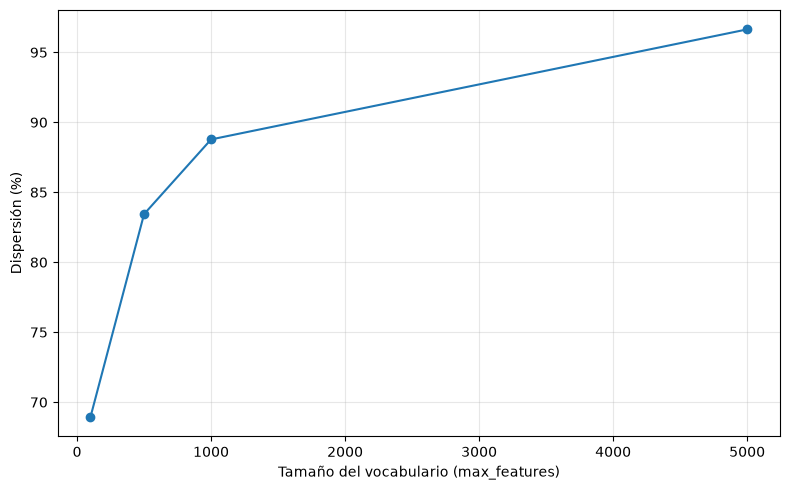

In [72]:
vocab_sizes = [100, 500, 1000, 5000]
sparsities = []

for n in vocab_sizes:
    vec_temp = CountVectorizer(lowercase=False, max_features=n)
    X_temp = vec_temp.fit_transform(corpus_normalizado)
    total = X_temp.shape[0] * X_temp.shape[1]
    sparsity_temp = (total - X_temp.nnz) / total * 100
    sparsities.append(sparsity_temp)
    print(f"Vocabulario = {n} -> Sparsity: {sparsity_temp:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(vocab_sizes, sparsities, marker='o')
plt.xlabel('Tamaño del vocabulario (max_features)')
plt.ylabel('Dispersión (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **¿Por qué crece la dispersión al aumentar el vocabulario? ¿Qué implicaciones tiene esto en el costo de almacenamiento y de cómputo?**: La dispercion crece porque cada ves que se aumenta el vocabulario porque se incorporan cada vez palabras mas raras que aparecen en pocos documentos. Esto genera una matriz con cada vez más valores cero, aumentando el espacio de almacenamiento necesario y haciendo que los cálculos sean más costosos y lentos.

- **¿Qué es una matriz dispersa (sparse matrix)? ¿Por qué se usan estructuras especiales (p. ej. formato CSR) en vez de matrices densas para este tipo de datos?**: Una matriz dispersa es una matriz donde la mayoria de los elementos son cero. Se utilizan estructuras especiales, como la del formato CSR, porque permiten almacenar unicamente los valores que son diferentes a 0 y sus pocisiones. Esto permite reducir el espacio de almacenamiento necesario y hacer calculos mas eficientes.

---
#### 3. N-gramas

In [73]:
# Unigramas
vectorizer_uni = CountVectorizer(lowercase=False, ngram_range=(1, 1))
X_uni = vectorizer_uni.fit_transform(corpus_normalizado)

# Bigramas
vectorizer_bi = CountVectorizer(lowercase=False, ngram_range=(2, 2))
X_bi = vectorizer_bi.fit_transform(corpus_normalizado)

print(f"Vocabulario unigramas: {X_uni.shape[1]}")
print(f"Vocabulario bigramas:  {X_bi.shape[1]}")

Vocabulario unigramas: 23412
Vocabulario bigramas:  227574


In [74]:
frecuencias_bi = np.asarray(X_bi.sum(axis=0)).flatten()
vocab_bi = vectorizer_bi.get_feature_names_out()

top_idx = np.argsort(frecuencias_bi)[::-1][:15]
top_bigramas = pd.DataFrame({
    'Bigrama': vocab_bi[top_idx],
    'Frecuencia': frecuencias_bi[top_idx]
})

top_bigramas

,Bigrama,Frecuencia
0,banco central,219
1,poder ser,201
2,bbva research,200
3,tasa interés,189
4,cada vez,184
5,entidad financiero,160
6,cambio climático,157
7,punto básico,139
8,año pasado,136
9,bbva méxico,134


- **¿Los bigramas aportan informacion que los unigramas (por si solos) no capturan?**: Algunos bigramas (como los de 'banco central', 'tasa interés', 'cambio climatica') si ofrecen mas informacion ya que capturan de mejor manera algunas relaciones semanticas que los unigramas pierden por ambiguedad.

- **¿Qué ventaja ofrecen los bigramas/trigramas frente a la bolsa de palabras clásica (unigramas)? ¿Qué costo tienen en tamaño de vocabulario?**: Los bigramas/trigramas caputran relaciones de contexto local y ayudan a reducir la ambiguedad que algunos terminos pierden al estar sueltas. El costo es un crecimiento rapido del tamaño de vocabulario, lo que lleva a una mayor dispercion en la matriz y un mayor costo de almacenamiento y computo.

---
#### 4. TF-IDF

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(lowercase=False)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_normalizado)

print(f"Shape TF-IDF: {X_tfidf.shape}")

Shape TF-IDF: (1137, 23412)


In [76]:
categorias_unicas = df[CATEGORY_COL].unique()

cats_elegidas = ["Macroeconomia", "Alianzas", "Innovacion"]
docs_idx = [df[df[CATEGORY_COL] == cat].index[0] for cat in cats_elegidas]

vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Top 10 palabras con mayor puntaje TF-IDF")
for idx, cat in zip(docs_idx, cats_elegidas):
    fila_tfidf = X_tfidf[idx].toarray().flatten()
    top10_idx = np.argsort(fila_tfidf)[::-1][:10]
    
    print(f"\nDocumento {idx} ({cat})")
    for i in top10_idx:
        print(f"- {vocab_tfidf[i]}: {fila_tfidf[i]:.4f}")

Top 10 palabras con mayor puntaje TF-IDF

Documento 3 (Macroeconomia)
- marzo: 0.2567
- ipc: 0.2363
- tasa: 0.2244
- mensual: 0.1901
- situar: 0.1615
- 95: 0.1602
- ipca: 0.1538
- punto: 0.1498
- pescado: 0.1384
- interanual: 0.1316

Documento 2 (Alianzas)
- viva: 0.3193
- aerolínea: 0.2467
- aerobus: 0.1968
- us50: 0.1782
- aviación: 0.1632
- low: 0.1488
- cost: 0.1428
- avión: 0.1379
- pasajero: 0.1365
- vivo: 0.1338

Documento 7 (Innovacion)
- agile: 0.4218
- nacho: 0.3307
- podcast: 0.2674
- alumno: 0.2629
- introducir: 0.2087
- legal: 0.1857
- thinktank: 0.1653
- nachir: 0.1653
- rrhh: 0.1653
- bondades: 0.1653


**¿Qué valor juegan estas palabras dentro de los artículos y como refleja su puntaje este papel?**

Estas palabras funcionan como etiquetas que ayudan a identificar de qué trata cada artículo. El puntaje refleja qué tan frecuente es una palabra dentro del documento y qué tan común es en relación con el resto del corpus. Mientras más alto sea el puntaje, más exclusiva y representativa es esa palabra de ese artículo en particular.

In [77]:
vocab_bow = vectorizer.get_feature_names_out()

print("Top 10 palabras mas frecuentes (conteo simple)")
for idx, cat in zip(docs_idx, cats_elegidas):
    fila_conteo = X_bow[idx].toarray().flatten()
    top10_idx = np.argsort(fila_conteo)[::-1][:10]
    
    print(f"\nDocumento {idx} ({cat})")
    for i in top10_idx:
        print(f"- {vocab_bow[i]}: {fila_conteo[i]}")

Top 10 palabras mas frecuentes (conteo simple)

Documento 3 (Macroeconomia)
- tasa: 8
- ipc: 7
- marzo: 7
- punto: 6
- mensual: 5
- situar: 4
- precio: 4
- impuesto: 3
- febrero: 3
- inflación: 3

Documento 2 (Alianzas)
- viva: 4
- año: 4
- aerolínea: 4
- modelo: 3
- trabajar: 3
- bajo: 3
- promedio: 2
- precio: 2
- ser: 2
- low: 2

Documento 7 (Innovacion)
- podcast: 3
- agile: 3
- sector: 2
- legal: 2
- varios: 2
- introducir: 2
- nacho: 2
- alumno: 2
- organización: 1
- publicación: 1


**¿Las 10 palabras con mayor puntaje TF-IDF coinciden con las 10 palabras más frecuentes (por conteo simple) de los mismos documentos? ¿Qué diferencias observa y por qué ocurren, según las fórmulas de TF e IDF vistas en clase?**

No coinciden completamente. Aunque algunas palabras aparecen en ambas listas, otras palabras tienen un puntaje TF-IDF alto aunque no sean las más frecuentes. Esto pasas porque el TF considera qué tan frecuente es una palabra dentro del documento, mientras que el IDF reduce el peso de las palabras que aparecen en muchos documentos del corpus.

**¿Por que es que TF-IDF penaliza palabras muy comunes en todo el corpus y favorece palabras raras pero repetidas dentro de un documento?**

TF-IDF penaliza las palabras comunes porque su valor IDF disminuye cuando una palabra aparece en muchos documentos. Una palabra que aparece varias veces en un documento pero en pocos documentos del corpus tiende a obtener un valor TF alto y un valor IDF alto.

---
#### 5. Similitud entre documentos (similitud coseno)

In [78]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_tfidf)
print(f"Shape matriz de similitud: {sim_matrix.shape}")

Shape matriz de similitud: (1137, 1137)


In [79]:
doc_ref_idx = 0
# doc_ref_idx = 3

cat_ref = df.loc[doc_ref_idx, CATEGORY_COL]

similitudes = sim_matrix[doc_ref_idx]

similitudes_sin_self = similitudes.copy()
similitudes_sin_self[doc_ref_idx] = -1

top5_idx = np.argsort(similitudes_sin_self)[::-1][:5]

print(f"Documento {doc_ref_idx} ({cat_ref})\n")

print("Documentos más similares:")
for i in top5_idx:
    print(f"- Doc {i} | Categoría: {df.loc[i, CATEGORY_COL]} | Similitud: {similitudes_sin_self[i]:.4f}")

coincidencias = sum(df.loc[i, CATEGORY_COL] == cat_ref for i in top5_idx)
print(f"\nCoincidencias de categoría: {coincidencias}/5")

Documento 0 (Otra)

Documentos más similares:
- Doc 544 | Categoría: Otra | Similitud: 0.3179
- Doc 1026 | Categoría: Sostenibilidad | Similitud: 0.2382
- Doc 1007 | Categoría: Otra | Similitud: 0.2201
- Doc 546 | Categoría: Sostenibilidad | Similitud: 0.2190
- Doc 858 | Categoría: Sostenibilidad | Similitud: 0.2149

Coincidencias de categoría: 2/5


In [80]:
cats_unicas = sorted(df[CATEGORY_COL].unique())
sim_por_categoria = pd.DataFrame(index=cats_unicas, columns=cats_unicas, dtype=float)

for c1 in cats_unicas:
    for c2 in cats_unicas:
        idx1 = df[df[CATEGORY_COL] == c1].index.values
        idx2 = df[df[CATEGORY_COL] == c2].index.values
        bloque = sim_matrix[np.ix_(idx1, idx2)]
        if c1 == c2:
            mask = ~np.eye(bloque.shape[0], dtype=bool)
            sim_por_categoria.loc[c1, c2] = bloque[mask].mean()
        else:
            sim_por_categoria.loc[c1, c2] = bloque.mean()

sim_por_categoria

,Alianzas,Innovacion,Macroeconomia,Otra,Regulaciones,Reputacion,Sostenibilidad
Alianzas,0.039230,0.037251,0.031905,0.038434,0.035257,0.038162,0.034263
Innovacion,0.037251,0.083087,0.040039,0.057978,0.040647,0.044000,0.052692
Macroeconomia,0.031905,0.040039,0.097142,0.051043,0.039944,0.042465,0.040799
Otra,0.038434,0.057978,0.051043,0.078553,0.040031,0.044213,0.048422
Regulaciones,0.035257,0.040647,0.039944,0.040031,0.054414,0.042090,0.036445
Reputacion,0.038162,0.044000,0.042465,0.044213,0.042090,0.119956,0.041545
Sostenibilidad,0.034263,0.052692,0.040799,0.048422,0.036445,0.041545,0.076958


**Explique ¿por qué se usa similitud coseno en lugar de distancia euclidiana para comparar documentos de distinta longitud?**

Se usa la similitud coseno porque mide el ángulo entre los vectores en vez de su magnitud. Esto significa que compara la proporción relativa de palabras sin verse afectada por la longitud del documento a diferencia de lla distancia euclidiana, que sí depende de la magnitud y por lo tanto termina penalizando a documentos largos aunque traten el mismo tema que uno corto.

---
---

## Laboratorio 3

#### 1. Conjuntos de entrenamiento, validación y prueba

In [81]:
from sklearn.model_selection import train_test_split

X = corpus_normalizado
y = df[CATEGORY_COL]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Número de documentos por conjunto:")
print(f"- Entrenamiento: {len(y_train)}")
print(f"- Validación:    {len(y_val)}")
print(f"- Prueba:        {len(y_test)}")
print(f"- Total:         {len(y_train) + len(y_val) + len(y_test)}")

Número de documentos por conjunto:
- Entrenamiento: 795
- Validación:    171
- Prueba:        171
- Total:         1137


In [82]:
conteos = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(),
    'Validación': y_val.value_counts(),
    'Prueba': y_test.value_counts(),
}).fillna(0).astype(int)

conteos

,Entrenamiento,Validación,Prueba
Type,,,
Alianzas,172,37,37
Innovacion,106,23,23
Macroeconomia,223,48,48
Otra,90,19,20
Regulaciones,99,21,21
Reputacion,18,4,4
Sostenibilidad,87,19,18


In [83]:
proporciones = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(normalize=True),
    'Validación': y_val.value_counts(normalize=True),
    'Prueba': y_test.value_counts(normalize=True),
}).fillna(0).round(4)

proporciones

,Entrenamiento,Validación,Prueba
Type,,,
Alianzas,0.2164,0.2164,0.2164
Innovacion,0.1333,0.1345,0.1345
Macroeconomia,0.2805,0.2807,0.2807
Otra,0.1132,0.1111,0.1170
Regulaciones,0.1245,0.1228,0.1228
Reputacion,0.0226,0.0234,0.0234
Sostenibilidad,0.1094,0.1111,0.1053


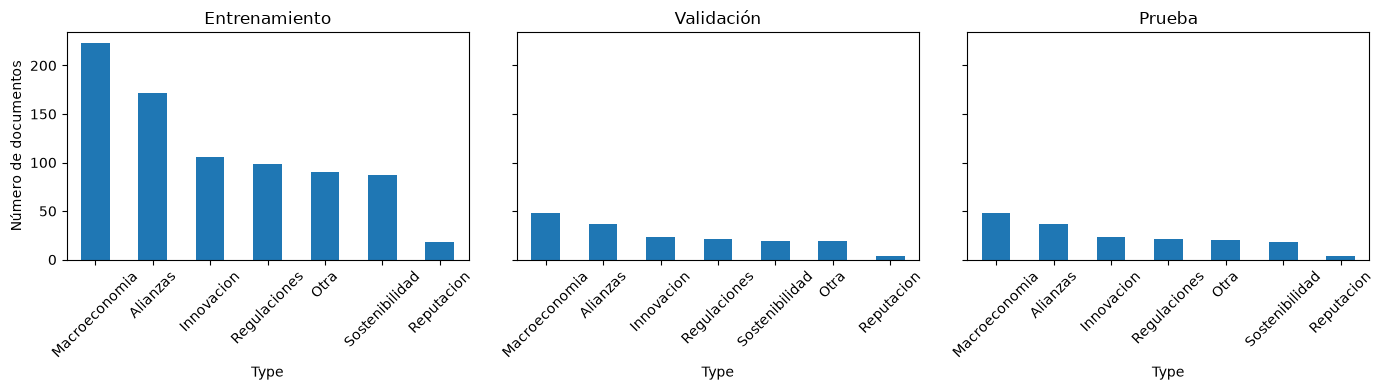

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (nombre, etiquetas) in zip(
    axes,
    [('Entrenamiento', y_train), ('Validación', y_val), ('Prueba', y_test)]
):
    etiquetas.value_counts().plot(kind='bar', ax=ax, title=nombre)
    ax.set_ylabel('Número de documentos')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Explique con sus propias palabras para qué sirve cada conjunto (entrenamiento, validación, prueba) y por qué no se debe usar el conjunto de prueba para tomar decisiones durante el desarrollo del modelo.**

Los conjuntos de entrenamiento, validación y prueba tienen diferentes objetivos. El conjunto de entrenamiento se utiliza para que el modelo pueda aprender los patrones presentes en el corpus. Por otro lado, el conjunto de validación se utiliza para comparar modelos, ajustar hiperparámetros o decidir cuándo detener el entrenamiento, por ejemplo, para evitar el sobreajuste. Por último, el conjunto de prueba se utiliza únicamente para medir qué tan bien generaliza el modelo cuando se le presentan datos que nunca ha visto. Este conjunto no debe utilizarse para tomar decisiones durante el desarrollo del modelo, ya que esto haría que dejara de ser una medida confiable de su capacidad de generalización. En ese caso, terminaría funcionando como un segundo conjunto de validación, sobre el cual también podría producirse un sobreajuste de manera involuntaria.

---

#### 2. Construcción del clasificador Naive Bayes

In [85]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

bow_vectorizer = CountVectorizer(lowercase=False)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

print("Modelo Naive Bayes (Bolsa de Palabras) entrenado.")
print(f"  Vocabulario: {len(bow_vectorizer.get_feature_names_out())} palabras")
print(f"  Categorías: {list(nb_bow.classes_)}")

Modelo Naive Bayes (Bolsa de Palabras) entrenado.
  Vocabulario: 19039 palabras
  Categorías: [np.str_('Alianzas'), np.str_('Innovacion'), np.str_('Macroeconomia'), np.str_('Otra'), np.str_('Regulaciones'), np.str_('Reputacion'), np.str_('Sostenibilidad')]


In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_train = TfidfVectorizer(lowercase=False)
X_train_tfidf = tfidf_vectorizer_train.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer_train.transform(X_val)
X_test_tfidf = tfidf_vectorizer_train.transform(X_test)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

print("Modelo Naive Bayes (TF-IDF) entrenado.")
print(f"  Vocabulario: {len(tfidf_vectorizer_train.get_feature_names_out())} palabras")
print(f"  Categorías: {list(nb_tfidf.classes_)}")

Modelo Naive Bayes (TF-IDF) entrenado.
  Vocabulario: 19039 palabras
  Categorías: [np.str_('Alianzas'), np.str_('Innovacion'), np.str_('Macroeconomia'), np.str_('Otra'), np.str_('Regulaciones'), np.str_('Reputacion'), np.str_('Sostenibilidad')]


**Explique, con sus propias palabras y apoyándose en el teorema de Bayes visto en clase, qué representan P(c) y P(wᵢ|c) en el contexto de este corpus de noticias, y cómo el modelo combina ambas probabilidades para clasificar un documento nuevo.**

P(c) es la probabilidad a priori de una categoría. Basicamente es qué tan frecuente es esa categoría dentro del conjunto de entrenamiento, sin tomar en cuenta el contenido del documento. P(wᵢ|c), por otro lado, es la probabilidad de observar una palabra específica (wᵢ) dado que el documento pertenece a la categoría c, se estima a partir de qué tan seguido aparece esa palabra en los documentos de entrenamiento de esa categoría en particular. Para clasificar un documento nuevo, el modelo aplica el teorema de Bayes en donde P(c|documento) es proporcional a P(c) multiplicado por el producto de P(wᵢ|c) de todas las palabras del documento. Combina qué tan probable es la categoría de antemano con qué tan probable es observar cada una de las palabras del documento si se asume que pertenece a esa categoría, asumiendo que las palabras son independientes entre sí. Este cálculo se repite para cada categoría posible, y el modelo asigna al documento la categoría que obtiene la probabilidad más alta.

---

#### 3. Entrenamiento y evaluación

In [87]:
from sklearn.metrics import classification_report

y_val_pred_bow = nb_bow.predict(X_val_bow)
y_val_pred_tfidf = nb_tfidf.predict(X_val_tfidf)

print("Reporte de clasificación — BoW (validación)")
print(classification_report(y_val, y_val_pred_bow))

print("Reporte de clasificación — TF-IDF (validación)")
print(classification_report(y_val, y_val_pred_tfidf))

Reporte de clasificación — BoW (validación)
                precision    recall  f1-score   support

      Alianzas       0.85      0.78      0.82        37
    Innovacion       0.70      1.00      0.82        23
 Macroeconomia       0.80      0.85      0.83        48
          Otra       0.80      0.63      0.71        19
  Regulaciones       0.83      0.71      0.77        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.89      0.89      0.89        19

      accuracy                           0.81       171
     macro avg       0.84      0.73      0.75       171
  weighted avg       0.82      0.81      0.80       171

Reporte de clasificación — TF-IDF (validación)
                precision    recall  f1-score   support

      Alianzas       0.67      0.65      0.66        37
    Innovacion       1.00      0.61      0.76        23
 Macroeconomia       0.41      1.00      0.59        48
          Otra       0.00      0.00      0.00        19
  Regulac

c:\Users\valde\miniforge3\envs\natural_language_processing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\valde\miniforge3\envs\natural_language_processing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\valde\miniforge3\envs\natural_language_processing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

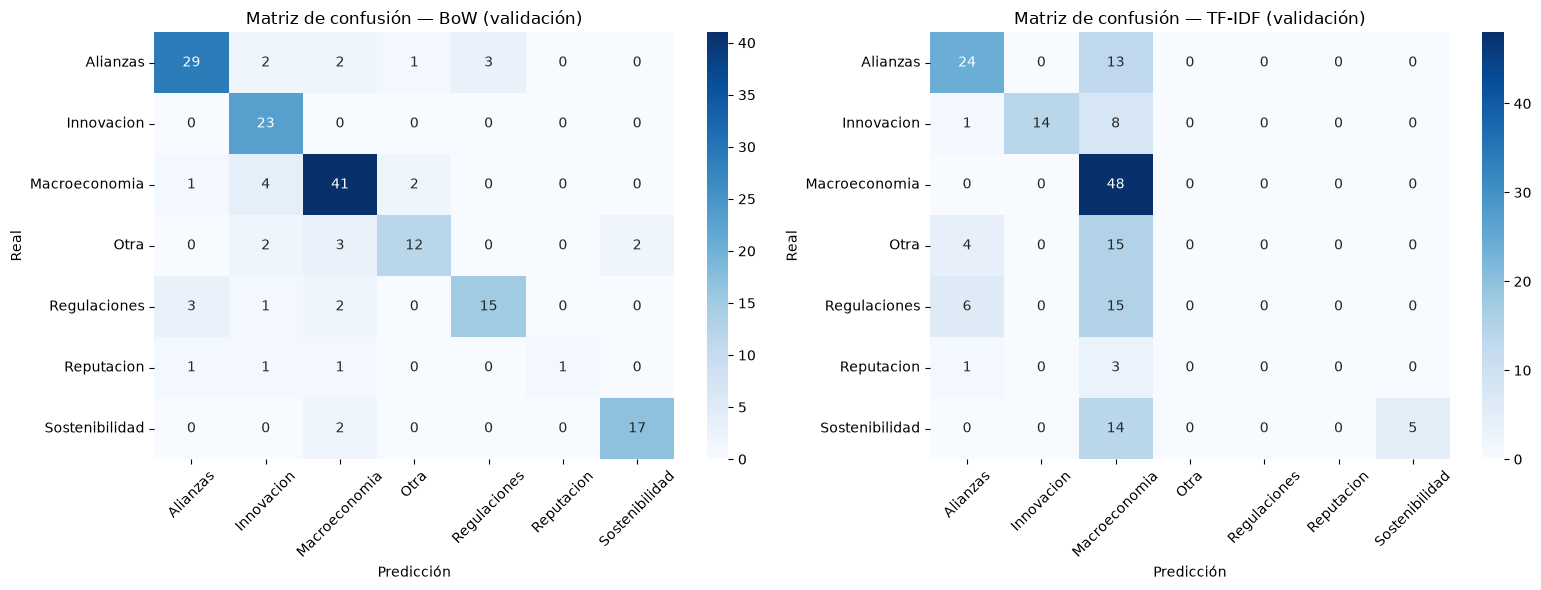

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

categorias_orden = sorted(y.unique())

cm_bow = confusion_matrix(y_val, y_val_pred_bow, labels=categorias_orden)
cm_tfidf = confusion_matrix(y_val, y_val_pred_tfidf, labels=categorias_orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[0])
axes[0].set_title('Matriz de confusión — BoW (validación)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[1])
axes[1].set_title('Matriz de confusión — TF-IDF (validación)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [89]:
from sklearn.metrics import accuracy_score, f1_score

y_train_pred_bow = nb_bow.predict(X_train_bow)
y_train_pred_tfidf = nb_tfidf.predict(X_train_tfidf)

comparacion = pd.DataFrame({
    'Modelo': ['BoW', 'BoW', 'TF-IDF', 'TF-IDF'],
    'Conjunto': ['Entrenamiento', 'Validación', 'Entrenamiento', 'Validación'],
    'Accuracy': [
        accuracy_score(y_train, y_train_pred_bow),
        accuracy_score(y_val, y_val_pred_bow),
        accuracy_score(y_train, y_train_pred_tfidf),
        accuracy_score(y_val, y_val_pred_tfidf),
    ],
    'F1 macro': [
        f1_score(y_train, y_train_pred_bow, average='macro'),
        f1_score(y_val, y_val_pred_bow, average='macro'),
        f1_score(y_train, y_train_pred_tfidf, average='macro'),
        f1_score(y_val, y_val_pred_tfidf, average='macro'),
    ],
})

comparacion

,Modelo,Conjunto,Accuracy,F1 macro
0,BoW,Entrenamiento,0.955975,0.950546
1,BoW,Validación,0.807018,0.748066
2,TF-IDF,Entrenamiento,0.695597,0.526759
3,TF-IDF,Validación,0.532164,0.345189


In [90]:
y_test_pred_bow = nb_bow.predict(X_test_bow)
y_test_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

print("Reporte de clasificación — BoW (prueba)")
print(classification_report(y_test, y_test_pred_bow))

print("Reporte de clasificación — TF-IDF (prueba)")
print(classification_report(y_test, y_test_pred_tfidf))

Reporte de clasificación — BoW (prueba)
                precision    recall  f1-score   support

      Alianzas       0.81      0.78      0.79        37
    Innovacion       0.74      1.00      0.85        23
 Macroeconomia       0.88      0.92      0.90        48
          Otra       0.90      0.45      0.60        20
  Regulaciones       0.94      0.76      0.84        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.65      0.94      0.77        18

      accuracy                           0.81       171
     macro avg       0.85      0.73      0.74       171
  weighted avg       0.83      0.81      0.80       171

Reporte de clasificación — TF-IDF (prueba)
                precision    recall  f1-score   support

      Alianzas       0.69      0.78      0.73        37
    Innovacion       0.94      0.70      0.80        23
 Macroeconomia       0.43      1.00      0.60        48
          Otra       0.00      0.00      0.00        20
  Regulaciones   

c:\Users\valde\miniforge3\envs\natural_language_processing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\valde\miniforge3\envs\natural_language_processing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\valde\miniforge3\envs\natural_language_processing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

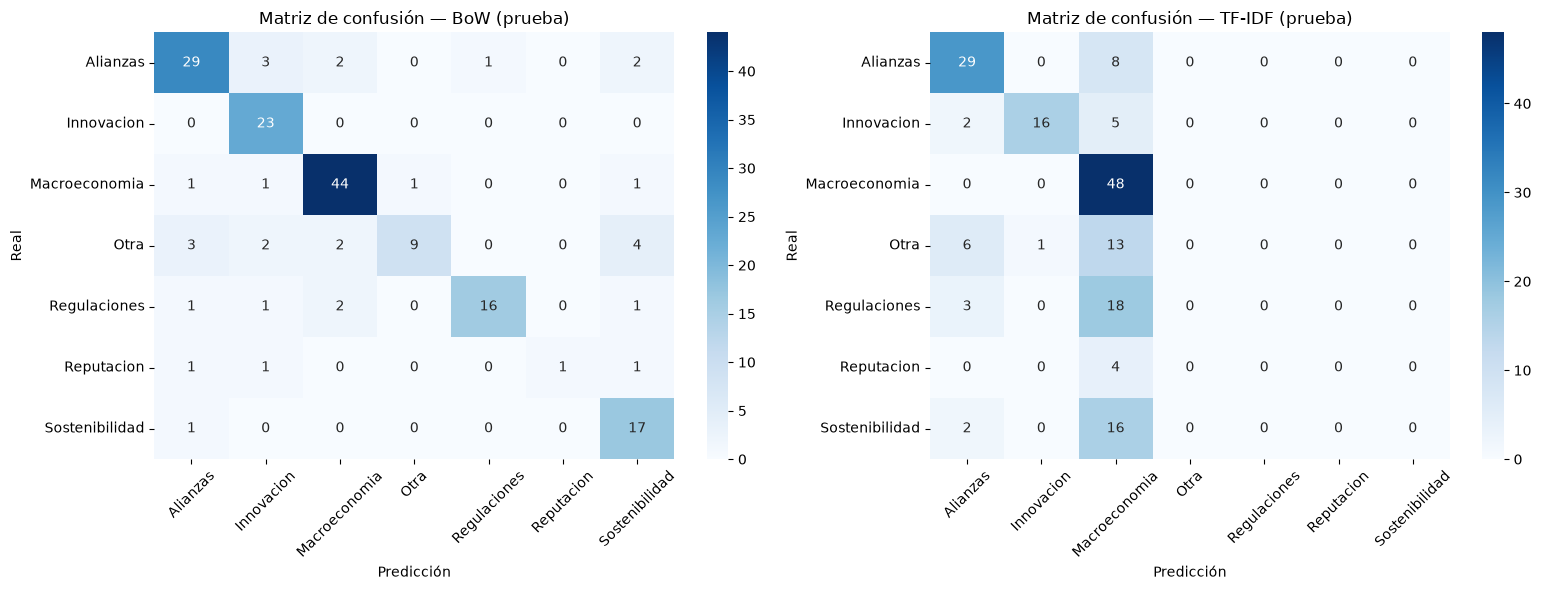

In [91]:
cm_bow_test = confusion_matrix(y_test, y_test_pred_bow, labels=categorias_orden)
cm_tfidf_test = confusion_matrix(y_test, y_test_pred_tfidf, labels=categorias_orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_bow_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[0])
axes[0].set_title('Matriz de confusión — BoW (prueba)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_tfidf_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[1])
axes[1].set_title('Matriz de confusión — TF-IDF (prueba)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Compare el desempeño en entrenamiento contra el desempeño en validación/prueba. ¿Hay indicios de overfitting? Relacione su respuesta con lo visto en clase sobre generalización.**

En entrenamiento, el modelo BoW obtuvo un accuracy de 0.96 y el de TF-IDF de 0.70, mientras que en validación bajaron a 0.81 y 0.53 respectivamente. Esta misma tendencia se mantiene en prueba, con un accuracy de 0.81 para BoW y 0.54 para TF-IDF. En el caso de BoW, sí hay indicios de overfitting, ya que pasa de un F1 de 0.95 en entrenamiento a 0.75 en validación, lo que significa que el modelo está memorizando en vez de aprender únicamente patrones que generalicen. Sin embargo, como sus resultados en validación y prueba son bastante similares, el sobreajuste no parece ser tan severo y el modelo todavía logra generalizar de manera razonable.

El modelo TF-IDF presenta un comportamiento diferente. Su accuracy en entrenamiento ya es más bajo que el de BoW, y en validación y prueba disminuye todavía más, hasta 0.53 y 0.54. Esto no parece ser un caso típico de overfitting, ya que el modelo tampoco obtiene un buen desempeño en entrenamiento. Más bien, los resultados sugieren que esta combinación de TF-IDF con MultinomialNB no funcionó bien para este corpus, ya que el modelo terminó favoreciendo principalmente a la categoría "Macroeconomia". Esto se puede observar en el reporte de clasificación, donde esta categoría tiene un recall de 1.00, mientras que otras como "Otra", "Regulaciones", "Reputacion" y "Sostenibilidad" obtienen precision y recall de 0.00 en prueba.


**Indique cuál de los dos modelos (BoW o TF-IDF) obtuvo mejor desempeño y proponga una explicación, en términos de cómo cada representación pondera las palabras.**

En cuanto al desempeño general, BoW fue el mejor modelo, ya que obtuvo valores más altos de accuracy y F1 macro en entrenamiento, validación y prueba. BoW representa directamente la frecuencia de aparición de las palabras, lo cual se adapta mejor a MultinomialNB. TF-IDF, en cambio, transforma estas frecuencias en valores ponderados que reducen la importancia de las palabras que aparecen en muchos documentos. En este corpus, algunas de esas palabras pueden seguir siendo útiles para distinguir entre categorías, por lo que reducir su peso termina afectando el desempeño del modelo. Por esta razón, BoW resultó ser la representación más adecuada para este caso.

---

### 4. Análisis de errores

In [92]:
mejor_nb = nb_bow
mejor_vectorizer = bow_vectorizer
y_true_analisis = y_test
y_pred_analisis = y_test_pred_bow
X_textos_analisis = X_test

cm_mejor = confusion_matrix(y_true_analisis, y_pred_analisis, labels=categorias_orden)
cm_sin_diag = cm_mejor.copy()
np.fill_diagonal(cm_sin_diag, 0)

i, j = np.unravel_index(np.argmax(cm_sin_diag), cm_sin_diag.shape)
cat_real, cat_pred = categorias_orden[i], categorias_orden[j]

print("Categorías más confundidas entre sí:")
print(f"  Real: '{cat_real}' -> Predicho: '{cat_pred}'  ({cm_sin_diag[i, j]} documentos)")
print(f"  Real: '{cat_pred}' -> Predicho: '{cat_real}'  ({cm_sin_diag[j, i]} documentos)")
print(f"  Total de confusiones cruzadas: {cm_sin_diag[i, j] + cm_sin_diag[j, i]}")

Categorías más confundidas entre sí:
  Real: 'Otra' -> Predicho: 'Sostenibilidad'  (4 documentos)
  Real: 'Sostenibilidad' -> Predicho: 'Otra'  (0 documentos)
  Total de confusiones cruzadas: 4


**Revise 3 a 5 documentos mal clasificados de esas categorías y comente qué palabras pudieron llevar al modelo a equivocarse.**

Las categorías que más se confunden entre sí son "Otra" y "Sostenibilidad". El modelo clasificó 4 documentos que realmente eran "Otra" como si fueran "Sostenibilidad", mientras que en sentido contrario no hubo ningún error. Al revisar estos 4 documentos, todos tratan sobre BBVA y contienen varias palabras relacionadas con sostenibilidad, como "sostenible", "sostenibilidad" o "energía", aunque el tema principal del artículo sea otro. Esto explica el error, ya que palabras como "agua" tienen una probabilidad mucho mayor bajo "Sostenibilidad" que bajo "Otra" (0.002670 frente a 0.000076), y lo mismo ocurre con "energía" (0.005106 frente a 0.000279) y "objetivo" (0.002508 frente a 0.000786). Aunque también aparecen palabras más relacionadas con "Otra", como "bbva", "banco" y "millón", la acumulación de varias palabras asociadas con sostenibilidad termina haciendo que el modelo favorezca esa categoría.

In [93]:
def palabras_sospechosas(texto_norm, cat_verdadera, cat_predicha, top_n=10):
    X_doc = mejor_vectorizer.transform([texto_norm])
    vocab = mejor_vectorizer.get_feature_names_out()

    idx_verdadera = np.where(mejor_nb.classes_ == cat_verdadera)[0][0]
    idx_predicha = np.where(mejor_nb.classes_ == cat_predicha)[0][0]

    cols = X_doc.nonzero()[1]
    candidatas = []
    for col in cols:
        cuenta = X_doc[0, col]
        p_verdadera = np.exp(mejor_nb.feature_log_prob_[idx_verdadera, col])
        p_predicha = np.exp(mejor_nb.feature_log_prob_[idx_predicha, col])
        candidatas.append((vocab[col], cuenta, p_verdadera, p_predicha))

    candidatas.sort(key=lambda x: x[3] * x[1], reverse=True)
    return candidatas[:top_n]

mask_err = (y_true_analisis == cat_real) & (y_pred_analisis == cat_pred)
indices_err = y_true_analisis[mask_err].index[:5]

print(f"Documentos mal clasificados: '{cat_real}' -> '{cat_pred}'\n")

for n, idx in enumerate(indices_err, 1):
    texto_norm = X_textos_analisis.loc[idx]

    print(f"--- Documento {n} (índice {idx}) ---")
    print(f"Texto original (extracto): {df.loc[idx, TEXT_COL][:300]}...")
    print(f"Texto normalizado (extracto): {texto_norm[:300]}...")

    sospechosas = palabras_sospechosas(texto_norm, cat_real, cat_pred)
    print("Palabras que pudieron influir en la predicción incorrecta:")
    for palabra, cuenta, p_real, p_pred in sospechosas:
        print(f"  - {palabra} (freq={cuenta}, P(w|{cat_real})={p_real:.6f}, P(w|{cat_pred})={p_pred:.6f})")
    print()

Documentos mal clasificados: 'Otra' -> 'Sostenibilidad'

--- Documento 1 (índice 988) ---
Texto original (extracto): Bbva ha actuado como banco coordinador en la financiación en formato project finance por US3799 millones 320 millones de euros  de Nabiax empresa de data centers en España y América Latina esta operación marca un hito en el sector de la tecnología de datos.Este project finance se convierte en sosten...
Texto normalizado (extracto): bbva actuado banco coordinador financiación formato project finance us3799 millón 320 millón euros nabiax empresa datar centers españa américa latina operación marca hito sector tecnologío datos.este project finance convertir sostenible vincular mecanismo precio tres indicador esg dos medioambiental...
Palabras que pudieron influir en la predicción incorrecta:
  - bbva (freq=3, P(w|Otra)=0.006791, P(w|Sostenibilidad)=0.005648)
  - millón (freq=5, P(w|Otra)=0.004941, P(w|Sostenibilidad)=0.002328)
  - sostenible (freq=2, P(w|Otra)=0.001900, P(w|

**Calcule y liste las palabras con mayor P(wᵢ|c) (verosimilitud) para dos o tres categorías del corpus. ¿Tienen sentido como palabras representativas de esa categoría?**

Para "Sostenibilidad", las palabras con mayor P(w|c) fueron "energía", "sostenible", "eléctrico", "sostenibilidad", "agua", "objetivo" y "cambio". Estas tienen sentido como palabras representativas porque están directamente relacionadas con temas ambientales y de sostenibilidad corporativa. Para "Macroeconomia", las palabras principales fueron "inflación", "precio", "tasa", "crecimiento", "económico" y "aumento", que también son términos esperables en noticias de esta categoría. Sin embargo, en ambas categorías y también en "Otra" aparecen palabras más generales como "bbva", "año", "poder", "hacer", "ser" y "él", que no son realmente distintivas.

In [94]:
def top_verosimilitud(modelo, vectorizer, categoria, n=15):
    idx = np.where(modelo.classes_ == categoria)[0][0]
    vocab = vectorizer.get_feature_names_out()
    log_probs = modelo.feature_log_prob_[idx]

    top_idx = np.argsort(log_probs)[::-1][:n]
    return pd.DataFrame({
        'Palabra': vocab[top_idx],
        'P(w|c)': np.exp(log_probs[top_idx]).round(6)
    })

cats_verosimilitud = list(dict.fromkeys([cat_real, cat_pred, 'Macroeconomia']))

for cat in cats_verosimilitud:
    print(f"\nTop palabras con mayor P(w|c) — categoría '{cat}':")
    print(top_verosimilitud(mejor_nb, mejor_vectorizer, cat).to_string(index=False))


Top palabras con mayor P(w|c) — categoría 'Otra':
   Palabra   P(w|c)
      bbva 0.006791
     banco 0.006208
    millón 0.004941
       año 0.003978
   entidad 0.003649
financiero 0.003623
   crédito 0.003167
     poder 0.002965
   cliente 0.002737
      tasa 0.002610
       mes 0.002357
     hacer 0.002306
  colombia 0.002230
   digital 0.002204
   tarjeta 0.002204

Top palabras con mayor P(w|c) — categoría 'Sostenibilidad':
       Palabra   P(w|c)
          bbva 0.005648
       energía 0.005106
    sostenible 0.004944
            él 0.004709
         poder 0.004637
           año 0.003104
     eléctrico 0.002743
           ser 0.002707
sostenibilidad 0.002670
          agua 0.002670
      objetivo 0.002508
         hacer 0.002454
        cambio 0.002400
       empresa 0.002382
        millón 0.002328

Top palabras con mayor P(w|c) — categoría 'Macroeconomia':
    Palabra   P(w|c)
  inflación 0.010695
     precio 0.008001
        año 0.007944
      poder 0.005753
       bbva 0.00438

**Relacione los errores encontrados con el supuesto de independencia condicional de Naive Bayes: ¿en qué casos cree que este supuesto "ingenuo" contribuyó a una clasificación incorrecta?**

Naive Bayes asume que cada palabra de un documento es independiente de las demás y utiliza la evidencia de cada una para calcular la probabilidad de cada categoría. En los 4 documentos de "Otra" que fueron clasificados como "Sostenibilidad", este supuesto pudo contribuir directamente al error, porque el modelo no puede considerar el contexto en el que aparecen las palabras. Por ejemplo, no puede distinguir entre un artículo que trata principalmente sobre sostenibilidad y uno que habla de un tema financiero pero menciona varias veces conceptos relacionados con sostenibilidad. El modelo únicamente observa palabras como "sostenible", "sostenibilidad", "agua", "energía" y "objetivo", y como varias de ellas tienen una alta probabilidad bajo "Sostenibilidad", la evidencia se va acumulando a favor de esa categoría.

---

### 5. Efecto de la representación de texto

In [95]:
import time

resultados_max_features = []

for n_features in [1000, 5000]:
    vectorizer_mf = CountVectorizer(lowercase=False, max_features=n_features)

    inicio = time.time()
    X_train_mf = vectorizer_mf.fit_transform(X_train)
    X_val_mf = vectorizer_mf.transform(X_val)

    nb_mf = MultinomialNB()
    nb_mf.fit(X_train_mf, y_train)
    tiempo_mf = time.time() - inicio

    y_val_pred_mf = nb_mf.predict(X_val_mf)

    resultados_max_features.append({
        'Representación': f'BoW (max_features={n_features})',
        'Vocabulario': len(vectorizer_mf.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_mf),
        'F1 macro': f1_score(y_val, y_val_pred_mf, average='macro'),
        'Tiempo (s)': round(tiempo_mf, 4)
    })

pd.DataFrame(resultados_max_features)

,Representación,Vocabulario,Accuracy,F1 macro,Tiempo (s)
0,BoW (max_features=1000),1000,0.830409,0.848993,0.1687
1,BoW (max_features=5000),5000,0.830409,0.849744,0.1725


In [96]:
resultados_ngramas = []

for nombre, ngram_range in [('Solo unigramas', (1, 1)), ('Unigramas + bigramas', (1, 2))]:
    vectorizer_ng = CountVectorizer(lowercase=False, ngram_range=ngram_range)

    inicio = time.time()
    X_train_ng = vectorizer_ng.fit_transform(X_train)
    X_val_ng = vectorizer_ng.transform(X_val)

    nb_ng = MultinomialNB()
    nb_ng.fit(X_train_ng, y_train)
    tiempo_ng = time.time() - inicio

    y_val_pred_ng = nb_ng.predict(X_val_ng)

    resultados_ngramas.append({
        'Representación': f'BoW ({nombre})',
        'Vocabulario': len(vectorizer_ng.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_ng),
        'F1 macro': f1_score(y_val, y_val_pred_ng, average='macro'),
        'Tiempo (s)': round(tiempo_ng, 4)
    })

pd.DataFrame(resultados_ngramas)

,Representación,Vocabulario,Accuracy,F1 macro,Tiempo (s)
0,BoW (Solo unigramas),19039,0.807018,0.748066,0.1645
1,BoW (Unigramas + bigramas),183394,0.766082,0.662177,0.9075


**¿Mejora el desempeño respecto al modelo de solo unigramas? ¿A qué costo, en tamaño de vocabulario y tiempo de entrenamiento?**

Agregar bigramas no mejoró el desempeño; al contrario, el accuracy bajó de 0.81 con solo unigramas a 0.77, mientras que el F1 macro disminuyó de 0.75 a 0.66. Además, el costo de utilizar bigramas fue considerable. El vocabulario aumentó de 19,039 a 183,394 términos, lo que representa casi 10 veces más términos, y el tiempo de entrenamiento pasó de 0.17 s a 0.78 s, por lo que el modelo tardó más de 4 veces en entrenarse.

Esto puede explicarse por el tamaño del corpus, ya que con solo unos cientos de documentos de entrenamiento muchos de los bigramas aparecen muy pocas veces. En lugar de aportar información útil para distinguir entre categorías, estos términos agregan más dispersión y generan muchas características que aparecen en pocos documentos. Esto dificulta que el modelo pueda estimar probabilidades confiables y puede afectar su capacidad de generalización. Tambien, Naive Bayes sigue tratando cada característica como evidencia independiente, por lo que agregar bigramas no significa que el modelo pueda comprender mejor el contexto de las palabras. En este caso, el aumento del vocabulario y del tiempo de entrenamiento no produjo ninguna mejora, sino que terminó reduciendo el desempeño del modelo.

In [98]:
class NaiveBayesMultinomial:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.clases_ = np.unique(y)
        n_clases = len(self.clases_)
        n_features = X.shape[1]

        self.log_prior_ = np.zeros(n_clases)
        self.log_likelihood_ = np.zeros((n_clases, n_features))

        for idx, clase in enumerate(self.clases_):
            X_clase = X[(y == clase).values]

            self.log_prior_[idx] = np.log(X_clase.shape[0] / X.shape[0])

            conteo_palabras = np.asarray(X_clase.sum(axis=0)).flatten()
            total_palabras = conteo_palabras.sum()

            self.log_likelihood_[idx] = np.log(
                (conteo_palabras + self.alpha) / (total_palabras + self.alpha * n_features)
            )

        return self

    def predict(self, X):
        log_posterior = X @ self.log_likelihood_.T + self.log_prior_
        indices_predichos = np.argmax(log_posterior, axis=1)
        return self.clases_[indices_predichos]

In [99]:
nb_propio = NaiveBayesMultinomial(alpha=1.0)
nb_propio.fit(X_train_bow, y_train)

y_val_pred_propio = nb_propio.predict(X_val_bow)

accuracy_propio = accuracy_score(y_val, y_val_pred_propio)
f1_propio = f1_score(y_val, y_val_pred_propio, average='macro')

print(f"Accuracy (implementación propia): {accuracy_propio:.4f}")
print(f"F1 macro (implementación propia): {f1_propio:.4f}")

print(f"\nAccuracy (sklearn MultinomialNB): {accuracy_score(y_val, y_val_pred_bow):.4f}")
print(f"F1 macro (sklearn MultinomialNB): {f1_score(y_val, y_val_pred_bow, average='macro'):.4f}")

Accuracy (implementación propia): 0.8070
F1 macro (implementación propia): 0.7481

Accuracy (sklearn MultinomialNB): 0.8070
F1 macro (sklearn MultinomialNB): 0.7481


In [100]:
tabla_comparativa = pd.DataFrame([
    {
        'Representación': 'BoW (vocabulario completo)',
        'Vocabulario': len(bow_vectorizer.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_bow),
        'F1 macro': f1_score(y_val, y_val_pred_bow, average='macro'),
    },
    {
        'Representación': 'TF-IDF (vocabulario completo)',
        'Vocabulario': len(tfidf_vectorizer_train.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_tfidf),
        'F1 macro': f1_score(y_val, y_val_pred_tfidf, average='macro'),
    },
] + resultados_max_features + resultados_ngramas)

tabla_comparativa.loc[len(tabla_comparativa)] = {
    'Representación': 'Implementación propia (BoW)',
    'Vocabulario': len(bow_vectorizer.get_feature_names_out()),
    'Accuracy': accuracy_propio,
    'F1 macro': f1_propio,
}

tabla_comparativa

,Representación,Vocabulario,Accuracy,F1 macro,Tiempo (s)
0,BoW (vocabulario completo),19039,0.807018,0.748066,NaN
1,TF-IDF (vocabulario completo),19039,0.532164,0.345189,NaN
2,BoW (max_features=1000),1000,0.830409,0.848993,0.1687
3,BoW (max_features=5000),5000,0.830409,0.849744,0.1725
4,BoW (Solo unigramas),19039,0.807018,0.748066,0.1645
5,BoW (Unigramas + bigramas),183394,0.766082,0.662177,0.9075
6,Implementación propia (BoW),19039,0.807018,0.748066,NaN
